In [1]:
import pandas as pd
import numpy as np
import holidays as hp
from xgboost import  XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.regularizers import L2
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import  TimeSeriesSplit
from tensorflow.keras.optimizers import SGD


2026-08-23 17:48:23.112494: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-23 17:48:23.744435: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-23 17:48:26.198949: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df = pd.read_csv('/home/purushottam/MACHINE LEARNING/TIME SERIES/COMPTETIONS/FAVORITA COMPETITONS/favo store sales.csv')

In [3]:
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
df = df.sample(n= 100000)

In [5]:
def process_data(df):
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    
    df_category = df.select_dtypes(include= 'str').columns
    df = pd.get_dummies(df, columns= df_category)
    
    q1 = df['sales'].quantile(0.25)
    q3 = df['sales'].quantile(0.75)

    iqr = q3 - q1

    upper = q3 + 1.5 * iqr

    lower = q1  - 1.5 * iqr

    df = df[(df['sales'] <= upper) & (df['sales'] >= 10)]

    
    return df



In [6]:
df = process_data(df)

In [7]:
us_holidays = hp.US(years = range(df['date'].dt.year.min() , df['date'].dt.year.max() + 2))

date_holidays = sorted(us_holidays.keys())

def days_to_holidays(date):

    future_holidays = [h for h in date_holidays if h >= date.date()]

    if future_holidays:
        return (future_holidays[0] - date.date()).days

    return None

    

In [8]:
def time(df):
    df['Month'] = df['date'].dt.month
    df['Year'] = df['date'].dt.year
    df['Dayofweek'] = df['date'].dt.dayofweek
    df['Dayofyear'] = df['date'].dt.dayofyear
    df['Day'] = df['date'].dt.day
    df['Quarter'] = df['date'].dt.quarter
    return df

def features_target(df):
    df['Target'] = df['sales'].shift(-1)
    df['Lag 1'] = df['sales'].shift(1)
    df['Lag 7'] = df['sales'].shift(7)
    df['Lag 30'] = df['sales'].shift(30)
    df['MA 7'] = df['sales'].shift(1).rolling(7).mean()
    df['MA 30'] = df['sales'].shift(1).rolling(30).mean()
    df['STD 7'] = df['sales'].shift(1).rolling(7).std()
    df['STD 30'] = df['sales'].shift(1).rolling(30).std()
    return df

def residuals_features_target(df):
    df['RLag 7'] = df['Residuals'].shift(7)
    df['RLag 30'] = df['Residuals'].shift(30)
    df['RMA 7'] = df['Residuals'].shift(1).rolling(7).mean()
    df['RMA 30'] = df['Residuals'].shift(1).rolling(30).mean()
    df['RSTD 7'] = df['Residuals'].shift(1).rolling(7).std()
    df['RSTD 30'] = df['Residuals'].shift(1).rolling(30).std()
    return df


In [9]:
train = df[(df['date'] >= '2013-01-01') & (df['date'] < '2016-03-01')]
val = df[(df['date'] >= '2016-03-01') & (df['date'] < '2017-01-01')]
test = df[(df['date'] >= '2017-01-01') & (df['date'] <= '2017-08-15')]

zero_std_cols = train.columns[train.std() == 0]

train = train.drop(columns= zero_std_cols)
val = val.drop(columns = zero_std_cols)
test = test.drop(columns= zero_std_cols)

In [10]:
train = features_target(train)
train = time(train)

val = features_target(val)
val = time(val)

test = features_target(test)
test = time(test)

train['Days_to_holidays'] = train['date'].apply(days_to_holidays)
val['Days_to_holidays'] = val['date'].apply(days_to_holidays)
test['Days_to_holidays'] = test['date'].apply(days_to_holidays)


train.dropna(inplace = True)
val.dropna(inplace= True)
test.dropna(inplace= True)

In [11]:
del train['date']
del val['date']
del test['date']

In [12]:
x_train = train.drop('Target', axis = 1)
y_train = train['Target']

x_val = val.drop('Target', axis = 1)
y_val = val['Target']

x_test = test.drop('Target', axis = 1)
y_test = test['Target']



In [13]:
def Time_Series_validate(x_train, y_train):
    
    tsv = TimeSeriesSplit(n_splits= 5)

    pred = np.full(len(x_train),np.nan)

    for fold,(train_idx, pred_idx) in enumerate(tsv.split(x_train)):
        x_tr = x_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]

        predi = x_train.iloc[pred_idx]

        model = XGBRegressor(n_estimators=  1500, learning_rate = 0.005, max_depth = 5)

        model.fit(x_tr, y_tr)

        pred[pred_idx] = model.predict(predi)

    return pred


In [14]:
time_train_pred = Time_Series_validate(x_train, y_train)

In [15]:
xgb = XGBRegressor(n_estimators = 1000, learning_rate = 0.005, max_depth = 7)
xgb.fit(x_train, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [17]:
pred_train = xgb.predict(x_train)
pred_val = xgb.predict(x_val)


In [18]:
mae_train = mean_absolute_error(y_train, pred_train)
print ("TRAIN ERROR:%.2f"%mae_train)
mae_val = mean_absolute_error(y_val, pred_val)
print ("VAL ERROR:%.2f"%mae_val)

TRAIN ERROR:96.04
VAL ERROR:106.86


In [19]:
train_lstm = train.copy()
val_lstm = val.copy()
test_lstm = test.copy()



In [20]:
train_lstm['Target'] = train_lstm['sales'].shift(-1)
val_lstm['Target'] = val_lstm['sales'].shift(-1)
test_lstm['Target'] = test_lstm['sales'].shift(-1)

In [21]:
train_lstm.dropna(inplace= True)
val_lstm.dropna(inplace= True)
test_lstm.dropna(inplace= True)

In [22]:
x_train_lstm = train_lstm.drop('Target', axis = 1)
y_train_lstm = train_lstm['Target']

x_val_lstm = val_lstm.drop('Target', axis = 1)
y_val_lstm = val_lstm['Target']

x_test_lstm = test_lstm.drop('Target', axis = 1)
y_test_lstm = test_lstm['Target']

In [23]:
zero_std_colss = x_train_lstm.columns[x_train_lstm.std() == 0]

x_train_lstm = x_train_lstm.drop(columns= zero_std_colss)

x_val_lstm = x_val_lstm.drop(columns= zero_std_colss)

x_test_lstm = x_test_lstm.drop(columns= zero_std_colss)

In [24]:
def window(x, y, window):
    x = np.array(x)
    y = np.array(y)

    x_seq = []
    y_seq = []

    for i in range(window, len(x)):
        x_seq.append(x[i - window : i])
        y_seq.append(y[i])

    return np.array(x_seq), np.array(y_seq)

In [32]:
x_mean = x_train_lstm.mean()
x_std = x_train_lstm.std()

x_train_sc = (x_train_lstm - x_mean) / x_std
x_val_sc = (x_val_lstm - x_mean) / x_std
x_test_sc = (x_test_lstm - x_mean) / x_std

y_mean = y_train_lstm.mean()
y_std = y_train_lstm.std()

y_train_sc = (y_train_lstm - y_mean) / y_std
y_val_sc = (y_val_lstm - y_mean) / y_std
y_test_sc = (y_test_lstm - y_mean) / y_std



In [33]:
x_train_sc, y_train_sc = window(x_train_sc, y_train_sc, 7)
x_val_sc, y_val_sc = window(x_val_sc, y_val_sc, 7)
x_test_sc, y_test_sc = window(x_test_sc, y_test_sc, 7)


In [39]:
lstm = Sequential()
lstm.add(LSTM(300,  activation= 'relu', input_shape = (x_train_sc.shape[1], x_train_sc.shape[2]),
 kernel_regularizer= L2(0.005), recurrent_regularizer= L2(0.005)))
lstm.add(Dense(256,  activation= 'relu'))
lstm.add(Dense(128,  activation= 'relu'))
lstm.add(Dense(90,  activation= 'relu'))
lstm.add(Dense(64,  activation= 'relu'))
lstm.add(Dropout(0.5))
lstm.add(Dense(32, activation= 'relu'))
lstm.add(Dense(16, activation= 'relu'))
lstm.add(Dense(1))

lstm.compile(optimizer= SGD(learning_rate = 0.009, clipvalue = 0.5, momentum= 0.7), loss= 'mean_absolute_error')



In [40]:
lstm.fit(x_train_sc, y_train_sc, epochs = 650, batch_size= 32)

Epoch 1/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 2.3999
Epoch 2/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.8463
Epoch 3/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.4839
Epoch 4/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.2460
Epoch 5/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.0917
Epoch 6/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.9892
Epoch 7/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.9229
Epoch 8/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.8791
Epoch 9/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.8502
Epoch 10/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.8317
Epoch 11/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.8194
Epoch 12/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.8113
Epoch 13/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.8062
Epoch 14/650
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.8028
Epoch 15/650
705/705 ━━━━━━━━━━━━━━━━━━━━

In [41]:
predict_train = lstm.predict(x_train_sc)
predict_val = lstm.predict(x_val_sc)

705/705 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
234/242 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

2026-08-24 02:51:06.099452: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_229', 8 bytes spill stores, 8 bytes spill loads



242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


In [44]:
predict_train = np.reshape(predict_train, (22545 ,))
predict_val = np.reshape(predict_val, (7724,))

In [45]:
predict_train = predict_train * y_std.item() + y_mean.item()
predict_val = predict_val * y_std.item() + y_mean.item()

In [46]:
y_final_train = train['Target'].iloc[8:].to_numpy()
y_final_val = val['Target'].iloc[38:].to_numpy()

In [47]:
final_predict_train = (0.6 * pred_train[8:] + 0.4 * predict_train)
final_predict_val = (0.6  * pred_val[31:] + 0.4 * predict_val[23:])

In [48]:
mae_train_lstm = mean_absolute_error(y_train_lstm.iloc[7:], predict_train)
print ('LSTM TRAIN ERROR:%.2f'%mae_train_lstm)
mae_val_lstm = mean_absolute_error(y_val_lstm.iloc[7:], predict_val)
print ("LSTM VAL ERROR:%.2f"%mae_val_lstm)

LSTM TRAIN ERROR:32.64
LSTM VAL ERROR:122.58


In [49]:
mae_final_train = mean_absolute_error(y_final_train, final_predict_train)
print ("TRAIN FINAL ERROR:%.2f"%mae_final_train)
mae_final_val = mean_absolute_error(y_final_val, final_predict_val[7:])
print ("VAL FINAL ERROR:%.2f"%mae_final_val)

TRAIN FINAL ERROR:103.13
VAL FINAL ERROR:107.56


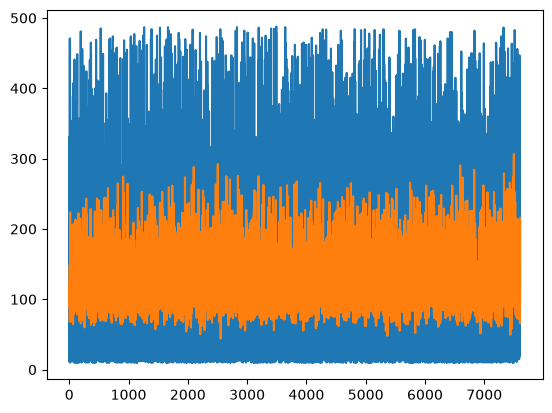

In [85]:
import matplotlib.pyplot as plt

plt.plot(y_final_val)
plt.plot(final_predict_val)

In [44]:
df['Target'] = df['sales'].shift(-1)
df['Persistence'] = df['Target'].shift(1).rolling(30).mean()
df.dropna(inplace= True)
mae_per = mean_absolute_error(df['Target'], df['Persistence'])
print ("PERSISTENCE ERROR:%.2f"%mae_per)

PERSISTENCE ERROR:105.11


In [60]:
final_predict_train.max()

np.float32(200.77591)

In [63]:
x_train_lstm

,id,store_nbr,sales,onpromotion,family_AUTOMOTIVE,family_BEAUTY,family_BEVERAGES,family_BREAD/BAKERY,family_CELEBRATION,family_CLEANING,...,MA 30,STD 7,STD 30,Month,Year,Dayofweek,Dayofyear,Day,Quarter,Days_to_holidays
5469,5469,12,126.006004,0,False,False,False,False,False,False,...,159.920667,110.915716,125.850627,1,2013,4,4,4,1,17
6613,6613,44,114.000000,0,False,False,False,False,False,False,...,158.254201,114.223508,125.961321,1,2013,4,4,4,1,17
5519,5519,14,157.000000,0,False,False,False,False,False,False,...,157.041967,115.316772,126.214584,1,2013,4,4,4,1,17
7042,7042,7,37.000000,0,False,False,False,False,False,False,...,161.841967,95.850790,123.251108,1,2013,4,4,4,1,17
7034,7034,7,378.426000,0,False,False,False,True,False,False,...,150.878301,105.375501,119.029108,1,2013,4,4,4,1,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2052266,2052266,41,44.130000,0,False,False,False,False,False,False,...,102.546800,104.744133,110.471210,2,2016,0,60,29,1,91
2051392,2051392,18,10.000000,0,False,False,False,False,False,False,...,103.651133,104.908434,109.687311,2,2016,0,60,29,1,91
2051196,2051196,12,12.000000,0,False,False,False,False,False,False,...,95.751133,106.028624,107.520201,2,2016,0,60,29,1,91
2052445,2052445,47,335.000000,1,False,False,False,False,False,False,...,88.951133,106.391931,106.094376,2,2016,0,60,29,1,91
